# Schmidt decomposition

## 1. Introduction

The Schmidt decomposition is one of the most important tools in quantum information theory. It provides a canonical way to write a **bipartite pure quantum state** and reveals the amount and structure of entanglement between two subsystems.

For a bipartite state shared between systems A and B,

\begin{equation}
|\psi\rangle_{AB} = 
\sum_{i,j} c_{ij}|i\rangle_A|j\rangle_B,
\end{equation}

the Schmidt decomposition rewrites it as

\begin{equation}
|\psi\rangle_{AB} = 
\sum_k \lambda_k |u_k\rangle_A |v_k\rangle_B,
\end{equation}

where:

* $\lambda_k$ are the **Schmidt coefficients**,
* $|u_k\rangle_A$ are orthonormal states of subsystem A,
* $|v_k\rangle_B$ are orthonormal states of subsystem B.

The Schmidt coefficients tell us immediately:

* if the state is entangled,
* how much entanglement exists,
* whether the entanglement is maximal.

---

# 2. Connection to Singular Value Decomposition (SVD)

The Schmidt decomposition is obtained by applying the matrix singular value decomposition.

For a two-qubit state:

\begin{equation}
|\psi\rangle = 
a|00\rangle+b|01\rangle+c|10\rangle+d|11\rangle,
\end{equation}

we construct the coefficient matrix
\begin{equation}
C=
\begin{bmatrix}
a & b\\
c & d
\end{bmatrix}
\end{equation}

Then we perform
\begin{equation}
C=U\Sigma V^\dagger
\end{equation}

where:
* U is unitary,
* V is unitary,
* $\Sigma$ is diagonal with nonnegative entries
\begin{equation}
\Sigma =
\begin{bmatrix}
\sigma_1 & 0 \\ 0 & \sigma_2
\end{bmatrix}
\end{equation}

The singular values $\sigma_i$ are exactly the Schmidt coefficients $\lambda_i$.

In Python, this is done using `numpy.linalg.svd()`.

---


The columns of U become the Schmidt basis of subsystem A: 

\begin{equation}
|u_i\rangle
\end{equation}

The columns of V become the Schmidt basis of subsystem B: 

\begin{equation}
|v_i\rangle
\end{equation}

V is obtained by taking the conjugate transpose of $V^\dagger$.

Therefore

\begin{equation}
|\psi_i \rangle = \lambda_i |u_i\rangle_A |v_i\rangle_B
\end{equation}

# 3. Calculation of Schmidt Decomposition in Python

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# The following function accepts a bipartite pure state and computes its Schmidt coefficients.

def schmidt_decomposition(state, dim_A, dim_B):
    """
    Schmidt decomposition of a bipartite pure state.

    Parameters:
        state : numpy array
            State vector
        dim_A : int
            Dimension of subsystem A
        dim_B : int
            Dimension of subsystem B

    Returns:
        U : Schmidt basis for A
        S : Schmidt coefficients
        Vh : Schmidt basis for B
    """

    # Reshape state vector into coefficient matrix
    coefficient_matrix = state.reshape(dim_A, dim_B)

    # Singular value decomposition
    U, S, Vh = np.linalg.svd(coefficient_matrix)

    return U, S, Vh

# 4. Example 1: Product state (no entanglement)

Consider
\begin{equation}
|\psi\rangle = |00\rangle .
\end{equation}

The coefficient matrix is
\begin{equation}
C=
\begin{bmatrix}
1&0\\
0&0
\end{bmatrix}.
\end{equation}

Performing SVD on C gives the Schmidt coefficients. 


In [5]:
state = np.array([
    1,0,
    0,0
])

U, S, Vh = schmidt_decomposition(state,2,2)

print(f"Schmidt coefficients: {S}")

Schmidt coefficients: [1. 0.]


Only one Schmidt coefficient is nonzero.

Therefore: Schmidt rank = 1 and the state is separable.

---

# 5. Example 2: Bell state (maximally entangled)

The Bell state is

\begin{equation}
|\Phi^+\rangle = 
\frac{|00\rangle+|11\rangle}{\sqrt2}.
\end{equation}

In [6]:
bell_state = np.array([
    1/np.sqrt(2),
    0,
    0,
    1/np.sqrt(2)
])

U, S, Vh = schmidt_decomposition(
    bell_state,
    2,
    2
)

print(f"Schmidt coefficients: {S}")

Schmidt coefficients: [0.70710678 0.70710678]


The Schmidt coefficients are equal, so the state is maximally entangled.

---

# 6. Example 3: Partially entangled state

Consider:

\begin{equation}
|\psi\rangle
= \sqrt{0.9}|00\rangle
+
\sqrt{0.1}|11\rangle
\end{equation}

In [7]:
state = np.array([
    np.sqrt(0.9),
    0,
    0,
    np.sqrt(0.1)
])

U, S, Vh = schmidt_decomposition(
    state,
    2,
    2
)

print(f"Schmidt coefficients: {S}")

Schmidt coefficients: [0.9486833  0.31622777]


The Schmidt coefficients are unequal, and therefore 
* the state is entangled,
* but not maximally entangled.

---

# 7. Computing entanglement entropy

Schmidt coefficients allow us to calculate entanglement entropy. This metric measures how strongly two subsystems of a pure quantum state are entangled. It quantifies the uncertainty, or "mixedness," that appears when we look at only one part of an entangled system and ignore the rest.

Entanglement entropy is a special case of von Neumann entropy. Von Neumann entropy measures the missing information in a general quantum state. More precisely, it quantifies the mixedness of a density matrix. Therefore, the entanglement entropy of a subsystem is defined as the von Neumann entropy of its reduced density matrix.

The general von Neumann entropy for any density matrix $\rho$ is defined as:

$$S(\rho) = -\text{Tr}(\rho \log_2 \rho)$$

By tracing out subsystem B, we obtain the reduced density matrix $\rho_A$:

$$\rho_A = \text{Tr}_B(\rho)$$

The eigenvalues of $\rho_A$ are exactly the squared Schmidt coefficients, $\lambda_i^2$. 

Because the trace of a matrix function depends only on its eigenvalues, we can calculate the entanglement entropy directly using the Schmidt coefficients:

$$S(\rho_A) = -\text{Tr}(\rho_A \log_2 \rho_A)= -\sum_i \lambda_i^2 \log_2(\lambda_i^2)$$

In [16]:
def von_neumann_entropy(S):
    """
    Calculate von Neumann entropy from Schmidt coefficients.
    Note: if S was obtained from a reduced density matrix, effectively this is entanglement entropy
    """

    probabilities = S**2

    entropy = 0

    for p in probabilities:
        if p > 0:
            entropy -= p*np.log2(p)

    return entropy

Bell state entropy: 

In [17]:
bell_state = np.array([
    1/np.sqrt(2),
    0,
    0,
    1/np.sqrt(2)
])

U, S, Vh = schmidt_decomposition(
    bell_state,
    2,
    2
)

entropy = von_neumann_entropy(S)

print(f"Bell state's von Neumann entropy: {entropy}")

Bell state's von Neumann entropy: 1.0


1 is the maximum possible entropy for a qubit. It implies a total loss of information. 

---

# 8. Schmidt decomposition of a three-qubit state

The Schmidt decomposition also works for multipartite systems if we choose a bipartition.

For example: $A|BC$

means:

* subsystem A is one qubit,
* subsystem BC is treated as one four-dimensional system.

The GHZ state is:

$$|GHZ\rangle
=
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

In [18]:
ghz = np.array([
    1/np.sqrt(2),
    0,
    0,
    0,
    0,
    0,
    0,
    1/np.sqrt(2)
])

U,S,Vh = schmidt_decomposition(
    ghz,
    2,
    4
)

print(f"Schmidt coefficients: {S}")

Schmidt coefficients: [0.70710678 0.70710678]


Therefore, across the partition $A|BC$ the GHZ state is maximally entangled.

However, the individual pairs AB, AC, and BC are not maximally entangled. This illustrates the difference between bipartite and multipartite entanglement.

---

# 9. Visualizing Schmidt spectrum

The Schmidt spectrum is the complete set of Schmidt coefficients. It provides a visual picture of entanglement. 

Because the sum of the squared coefficients must always equal 1, the shape of this spectrum gives an immediate, intuitive picture of the entanglement present in the system:

* **Product state**: The spectrum has only one non-zero value, which is exactly 1. This means the state is completely unentangled.

* **Weakly entangled state**: The spectrum has one very large coefficient dominating the others. This indicates the system is mostly localized in one state, with only slight quantum correlations.

* **Maximally entangled state**: The spectrum is perfectly flat. All non-zero Schmidt coefficients are perfectly equal. This represents maximum uncertainty locally and maximum entanglement globally.

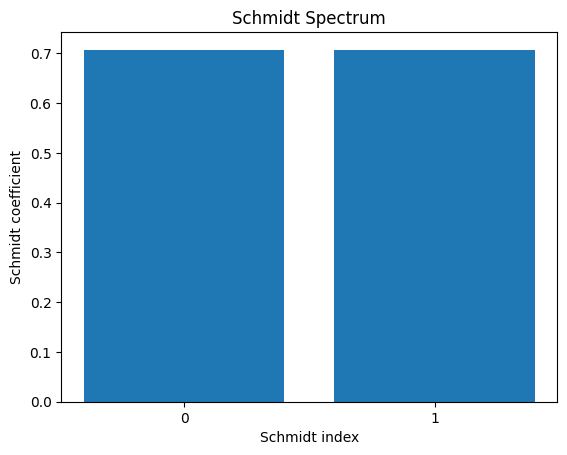

In [21]:
plt.bar(range(len(S)), S)

# Schmidt index is the index k in lambda_k
plt.xlabel("Schmidt index")
plt.ylabel("Schmidt coefficient")
plt.title("Schmidt Spectrum")

# Force integer labels:
plt.xticks(range(len(S)))

plt.show()

<div style="background-color:#f0f0f0; padding:10px; border-radius:5px;">
This code is a part of Quantum AI Biomedical Research Lab project 
    
`Estimating molecular ground and excited state energies on quantum computers'
    
© Copyright Renata Wong, 2026.

This code is licensed under the CC BY-NC 4.0 License. You may
obtain a copy of this license in the LICENSE.txt file in the root directory
of this source tree or at https://creativecommons.org/licenses/by-nc/4.0/deed.en.

Any modifications or derivative works of this code must retain this
copyright notice, and modified files need to carry a notice indicating
that they have been altered from the originals.
</div>

<div style="background-color:#f0f0f0; padding:10px; border-radius:5px;">
This work was supported by the National Science and Technology Council (Taiwan) grant No. NSTC 114-2112-M-182-002-MY3 and Chang Gung Memorial Hospital grant No. BMRPL94.

This work comes with an accompanying paper titled 'Quantum circuit compilation for fermionic excitations using the Jordan-Wigner mapping'.
</div>